In [205]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from os import listdir, remove
from os.path import isfile, join
from pathlib import Path

### Old

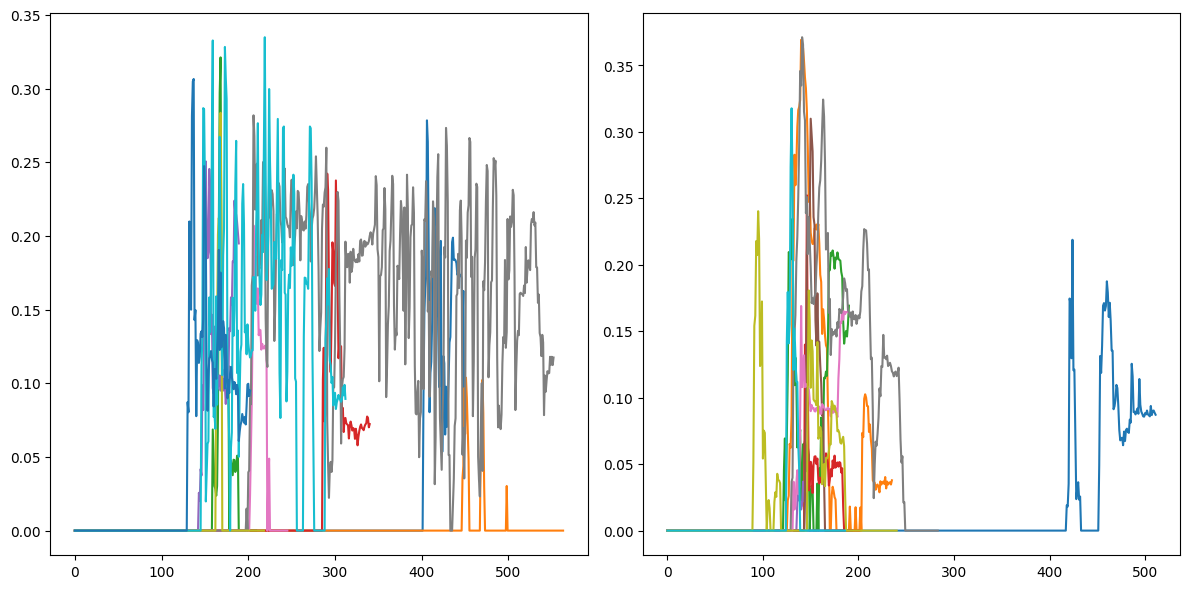

In [15]:
log_path = '/home/hyperdog/octo/logs/tomato/'
forcefullpath = log_path + 'forcefull/'
forcelesspath = log_path +'forceless/'
forcefiles = [f for f in listdir(forcefullpath) if isfile(join(forcefullpath, f))]
forcelessfiles = [f for f in listdir(forcelesspath) if isfile(join(forcelesspath, f))]
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
for file in forcefiles:
    data = np.load(forcefullpath + file, allow_pickle=True)
    axs[0].plot(data)
for file in forcelessfiles:
    data = np.load(forcelesspath + file, allow_pickle=True)
    axs[1].plot(data)

plt.tight_layout()
plt.show()

In [16]:
min = 500
for file in forcelessfiles:
    data = np.load(log_path + 'forceless/' + file, allow_pickle=True)
    if data[-1] == 0:
        print(file)

episode_3.npy
episode_8.npy
episode_9.npy
episode_2.npy
episode_5.npy
episode_1.npy


In [ ]:
data = np.load(log_path + 'forceless/' + "episode_4.npy", allow_pickle=True)
plt.plot(data)

In [106]:
# sum = np.zeros(40)
# for file in forcefiles:
#     data = np.load(log_path + 'forcefull/' + file, allow_pickle=True)
#     for i in range(len(data)):
#         if data[i] > 0:
#             sum+=data[i:i+40]
#             # print(len(data[i:]))
#             # print(file)
#             break
# plt.plot(sum / len(forcefiles))

sum = np.zeros(100)
for file in forcelessfiles:
    data = np.load(log_path + 'forceless/' + file, allow_pickle=True)
    for i in range(len(data)):
        if data[i] > 0:
            # sum+=data[i:i+100]
            # print(len(data[i:]))
            print(i)
            print(file)
            break
# plt.plot(sum / len(forcelessfiles))

0
episode_24.npy
0
episode_6.npy
0
episode_17.npy
0
episode_10.npy
0
episode_3.npy
0
episode_12.npy
0
episode_16.npy
0
episode_22.npy
0
episode_19.npy
0
episode_8.npy
0
episode_11.npy
0
episode_18.npy
0
episode_14.npy
0
episode_21.npy
0
episode_15.npy
0
episode_7.npy
0
episode_2.npy
0
episode_23.npy


### Log Force

In [192]:
def calc_averaged_curve(path):
    files = [f for f in listdir(path) if isfile(join(path, f))]
    sum = np.zeros(500)
    for file in files:
        data = np.load(path + file, allow_pickle=True)
        for i in range(len(data)):
            if data[i] > 0:
                sum+= np.concatenate([np.zeros(10), data[i:], np.full(500 -10 - len(data[i:]), data[-1])])
                break
    return sum[:100] / len(files)

In [ ]:
log_path = '/home/hyperdog/octo/logs_copy/tomato/'
data = np.load(log_path + 'forcefull/' + "episode_10.npy", allow_pickle=True)
plt.plot(data)

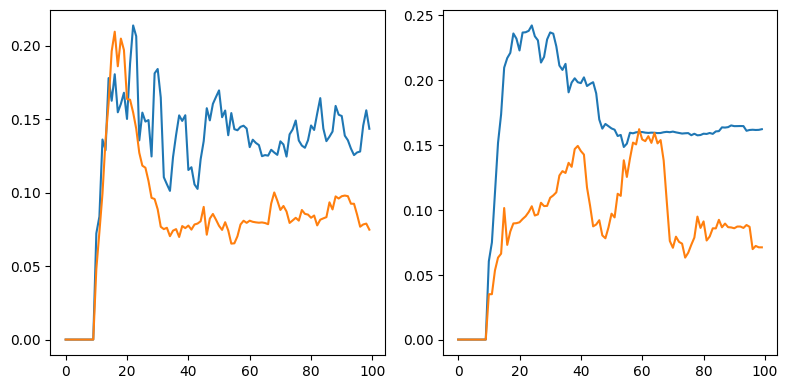

In [204]:
log_path = '/home/hyperdog/octo/logs_copy/'
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].plot(calc_averaged_curve(log_path + "tomato/" + 'forcefull/'))
axs[0].plot(calc_averaged_curve(log_path + "tomato/" + 'forceless/'))
axs[1].plot(calc_averaged_curve(log_path + "toothpaste/" + 'forcefull/'))
axs[1].plot(calc_averaged_curve(log_path + "toothpaste/" + 'forceless/'))

plt.tight_layout()
plt.show()

### Log force and gripper pose

In [440]:
def calc_averaged_force(path):
    files = [f for f in listdir(path) if isfile(join(path, f))]
    sum = np.zeros(500)
    for file in files:
        data = np.load(path + file, allow_pickle=True)
        for i in range(len(data)):
            if data[i, -1] > 0:
                sum+= np.concatenate([np.zeros(10), data[i:, -1], np.full(500 -10 - len(data[i:]), data[-1, -1])])
                break
    return sum[:70] / len(files)

def calc_averaged_position(path):
    files = [f for f in listdir(path) if isfile(join(path, f))]
    sum = np.zeros(500)
    for file in files:
        data = np.load(path + file, allow_pickle=True)
        for i in range(len(data)):
            if data[i, -2] > 0.03:
                sum+= np.concatenate([np.zeros(10), data[i:, -2], np.full(500 -10 - len(data[i:]), data[-1, -2])])
                break
    return sum[:70] / len(files)

def calc_averaged_force_expert(path):
    files = [f for f in listdir(path) if isfile(join(path, f))]
    sum = np.zeros(500)
    for file in files:
        data = np.load(path + file, allow_pickle=True)
        force_data = [data[i]['state'][-1] for i in range(len(data))]
        for i in range(len(data)):
            if force_data[i] > 0:
                sum+= np.concatenate([np.zeros(10), force_data[i:], np.full(500 -10 - len(force_data[i:]), force_data[-1])])
                break
    return sum[:100] / len(files)

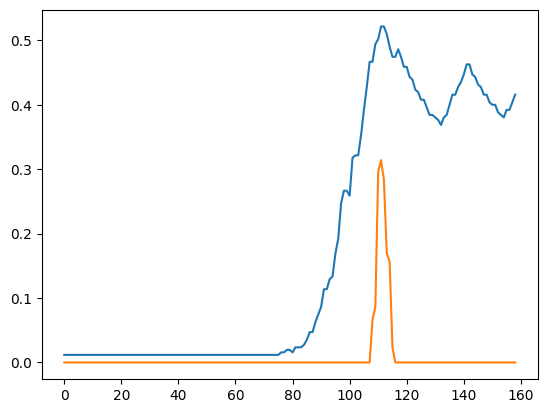

In [434]:
# log_path = '/home/hyperdog/octo/logs/shampoo/position/episode_5.npy'
log_path = '/home/hyperdog/octo/logs/shampoo/force/episode_6.npy'
# log_path = '/home/hyperdog/octo/logs/shampoo/force/episode_5.npy'
data = np.load(log_path, allow_pickle=True)
plt.plot(data[:, 0])
plt.plot(data[:, 1])

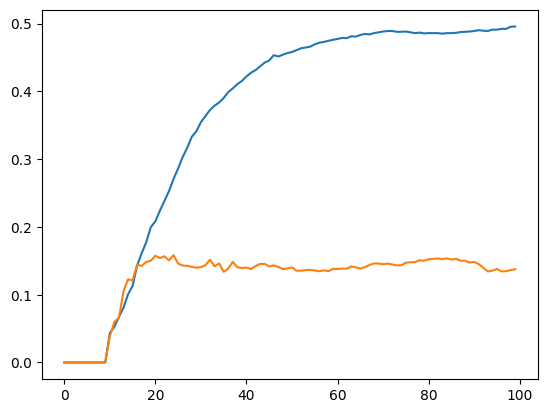

In [317]:
log_path = '/home/hyperdog/octo/logs/toothpaste/'
plt.plot(calc_averaged_position(log_path + "position/"))
plt.plot(calc_averaged_force(log_path + "position/"))

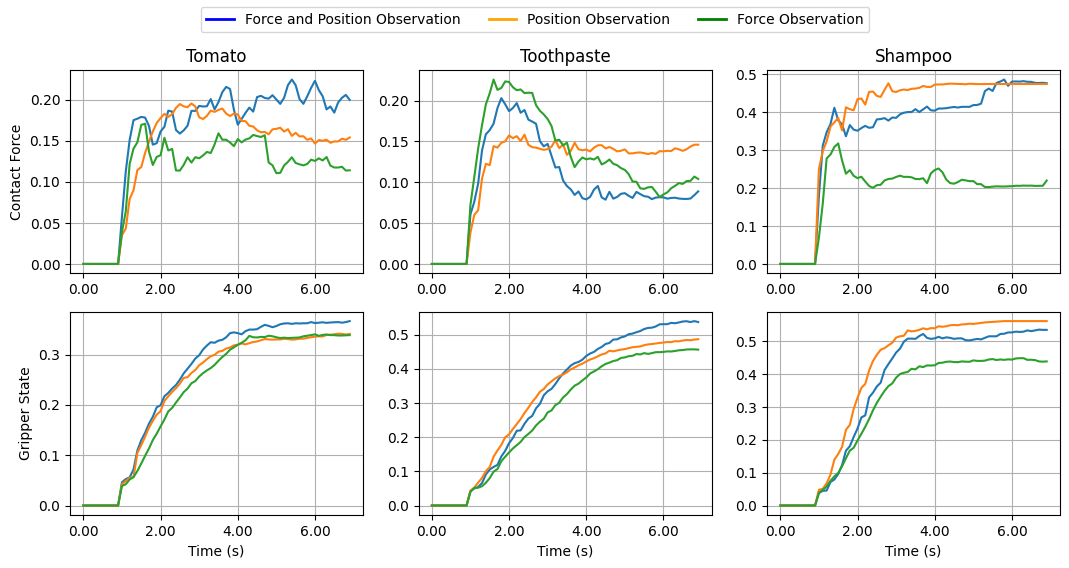

In [441]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

log_path = '/home/hyperdog/octo/logs/'
fig, axs = plt.subplots(2, 3, figsize=(12, 6))

# plot force
axs[0, 0].plot(calc_averaged_force(log_path + "tomato/" + 'force_and_position/'), label="force_and_position")
axs[0, 0].plot(calc_averaged_force(log_path + "tomato/" + 'position/'), label="position")
axs[0, 0].plot(calc_averaged_force(log_path + "tomato/" + 'force/'), label="force")

axs[0, 1].plot(calc_averaged_force(log_path + "toothpaste/" + 'force_and_position/'), label="force_and_position")
axs[0, 1].plot(calc_averaged_force(log_path + "toothpaste/" + 'position/'), label="position")
axs[0, 1].plot(calc_averaged_force(log_path + "toothpaste/" + 'force/'), label="force")

axs[0, 2].plot(calc_averaged_force(log_path + "shampoo/" + 'force_and_position/'), label="force_and_position")
axs[0, 2].plot(calc_averaged_force(log_path + "shampoo/" + 'position/'), label="position")
axs[0, 2].plot(calc_averaged_force(log_path + "shampoo/" + 'force/'), label="force")

# plot gripper pose
axs[1, 0].plot(calc_averaged_position(log_path + "tomato/" + 'force_and_position/'), label="force and position")
axs[1, 0].plot(calc_averaged_position(log_path + "tomato/" + 'position/'), label="position")
axs[1, 0].plot(calc_averaged_position(log_path + "tomato/" + 'force/'), label="force")

axs[1, 1].plot(calc_averaged_position(log_path + "toothpaste/" + 'force_and_position/'), label="force and position")
axs[1, 1].plot(calc_averaged_position(log_path + "toothpaste/" + 'position/'), label="position")
axs[1, 1].plot(calc_averaged_position(log_path + "toothpaste/" + 'force/'), label="force")

axs[1, 2].plot(calc_averaged_position(log_path + "shampoo/" + 'force_and_position/'), label="force and position")
axs[1, 2].plot(calc_averaged_position(log_path + "shampoo/" + 'position/'), label="position")
axs[1, 2].plot(calc_averaged_position(log_path + "shampoo/" + 'force/'), label="force")

# Установка подписей осей Y
for ax in axs[:, 0]:
    ax.set_ylabel('Contact Force')

axs[1, 0].set_ylabel('Gripper State')

# Установка подписей осей X
for ax in axs[-1]:
    ax.set_xlabel('Time (s)')

# Функция для деления значений по оси X на 13
def format(x, pos):
    return f'{x / 10:.2f}'

formatter = FuncFormatter(format)

# Применяем форматтер ко всем осям X
for ax in axs.flatten():
    ax.xaxis.set_major_formatter(formatter)

# Добавление заголовков над столбцами
column_titles = ['Tomato', 'Toothpaste', 'Shampoo']
for ax, title in zip(axs[0], column_titles):
    ax.set_title(title)

# Общая легенда
handles = [plt.Line2D([0], [0], color='blue', lw=2),
           plt.Line2D([0], [0], color='orange', lw=2),
           plt.Line2D([0], [0], color='green', lw=2)]
labels = ["Force and Position Observation", "Position Observation", "Force Observation"]
fig.legend(handles=handles, labels=labels, loc='upper center', ncol=3)

# Включение линий сетки на каждом графике
for ax in axs.flatten():
    ax.grid(True)

plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95]) # Убедитесь что легенда не перекрывает графики
plt.show()

In [395]:
def calc_max(path):
    files = [f for f in listdir(path) if isfile(join(path, f))]
    max_force = 0
    for file in files:
        data = np.load(path + file, allow_pickle=True)
        if max_force < max(data[:, -1]):
            max_force = max(data[:, -1])
    return max_force

In [397]:
log_path = '/home/hyperdog/octo/logs/'
print(calc_max(log_path + "tomato/" + 'force_and_position/'))
print(calc_max(log_path + "tomato/" + 'position/'))
print(calc_max(log_path + "tomato/" + 'force/'))

0.3750915825366974
0.5951160192489624
0.34285715222358704


In [398]:
log_path = '/home/hyperdog/octo/logs/'
print(calc_max(log_path + "toothpaste/" + 'force_and_position/'))
print(calc_max(log_path + "toothpaste/" + 'position/'))
print(calc_max(log_path + "toothpaste/" + 'force/'))

0.3990232050418854
0.4283272325992584
0.4256410300731659


In [399]:
log_path = '/home/hyperdog/octo/logs/'
print(calc_max(log_path + "shampoo/" + 'force_and_position/'))
print(calc_max(log_path + "shampoo/" + 'position/'))
print(calc_max(log_path + "shampoo/" + 'force/'))

0.6090354323387146
0.620512843132019
0.6490842700004578
